In [1]:
import sys
import os

from PIL.GimpGradientFile import linear
from pandas.core.common import random_state

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')


import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a depende

In [2]:
X1 = pd.read_csv("mod_data/X1.1")
X2 = pd.read_csv("mod_data/X2.1")
X3 = pd.read_csv("mod_data/X3.1")
y1 = pd.read_csv("mod_data/y1.1")["Y"]
y2 = pd.read_csv("mod_data/y2.1")["Y"]
y3 = pd.read_csv("mod_data/y3.1")["Y"]


In [3]:
X1.index = X1.QSPRID
X2.index = X2.QSPRID
X3.index = X3.QSPRID
X1 = X1.drop(columns=["Unnamed: 0", "QSPRID"])
X2 = X2.drop(columns=["Unnamed: 0", "QSPRID"])
X3 = X3.drop(columns=["Unnamed: 0", "QSPRID"])

In [4]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [5]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit(X1)
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1

In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

In [7]:
n_components

3127

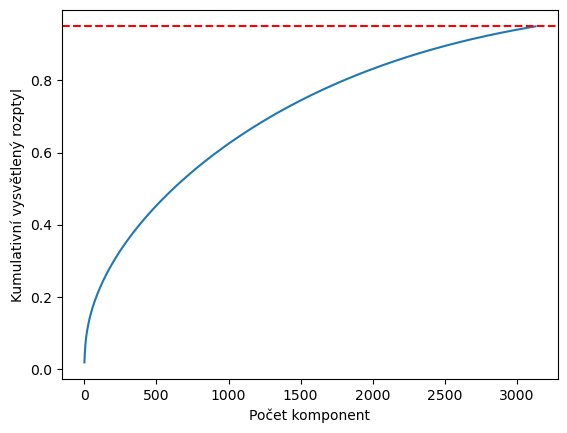

In [8]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [1]:
import numpy as np

# Read the data back from the CSV file
X1 = np.genfromtxt('X1.csv', delimiter=',')
X2 = np.genfromtxt('X2.csv', delimiter=',')
X3 = np.genfromtxt('X3.csv', delimiter=',')

In [2]:
y1 = np.genfromtxt('y1.csv', delimiter=',')
y2 = np.genfromtxt('y2.csv', delimiter=',')
y3 = np.genfromtxt('y3.csv', delimiter=',')

In [4]:
from sklearn.svm import LinearSVC
from sklearn.metrics import matthews_corrcoef

svm = LinearSVC()
svm.fit(X1, y1)
print(matthews_corrcoef(svm.predict(X2),y2))
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV # For tuning


# Tune C parameter using GridSearchCV
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_search_linear_svc = GridSearchCV(LinearSVC(max_iter=5000), param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search_linear_svc.fit(X1, y1)
print(f"Best C for LinearSVC: {grid_search_linear_svc.best_params_['C']}")
print("LinearSVC trained.")

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.11121609377798182
Fitting 3 folds for each of 6 candidates, totalling 18 fits


/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dua

Best C for LinearSVC: 0.001
LinearSVC trained.


In [7]:
print(matthews_corrcoef(grid_search_linear_svc.best_estimator_.predict(X2),y2))

0.31007043321600064


In [32]:
import random
import time
import warnings
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, accuracy_score, matthews_corrcoef
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning

# Potlačení varování o konvergenci pro čistší výstup
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Definuje prostor hyperparametrů pro ladění
param_space_svc = {
    'C': np.logspace(np.log10(0.001), np.log10(100), num=20).tolist(),
    'loss': ['hinge', 'squared_hinge'],
    'penalty': ['l1', 'l2'],
    'dual': [False],  # Ponecháno False, což je efektivnější, když počet vzorků > počet příznaků
    'tol': np.logspace(np.log10(1e-5), np.log10(1e-2), num=10).tolist(),
    'multi_class': ['ovr'],
    'fit_intercept': [True, False],
    'intercept_scaling': [1],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000, 5000, 10000],
    'random_state': [69],
}

def generate_random_params_svc(param_space_dict):
    """
    Generuje náhodnou sadu hyperparametrů a zajišťuje validní kombinace pro LinearSVC.
    """
    params = {}
    for param_name, values in param_space_dict.items():
        params[param_name] = random.choice(values)

    # KLÍČOVÁ LOGIKA: Automaticky opravuje nevalidní kombinace parametrů.
    # Pokud je `dual=False`, `penalty='l2'` a `loss='hinge'`, změní `loss` na `squared_hinge`,
    # což je podporovaná kombinace.
    if params['penalty'] == 'l2' and params['loss'] == 'hinge' and not params['dual']:
        params['loss'] = 'squared_hinge'

    # Další omezení: `penalty='l1'` vyžaduje `dual=False`.
    # Jelikož `dual` je ve vašem prostoru napevno `False`, toto je již splněno.
    if params['penalty'] == 'l1':
        params['dual'] = False
        
    return params

def custom_objective_svc(current_params, X_train, y_train, X_val, y_val):
    """
    Trénuje a vyhodnocuje model LinearSVC s danými parametry.
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    try:
        model = LinearSVC(**current_params, random_state=69)
        model.fit(X_train_scaled, y_train)

        # OPRAVA: Použijte metodu .predict() pro získání binárních predikcí.
        preds_bin = model.predict(X_val_scaled)

        # Výpočet metrik
        f1 = f1_score(y_val, preds_bin)
        acc = accuracy_score(y_val, preds_bin)
        mcc = matthews_corrcoef(y_val, preds_bin)

        return {'f1': f1, 'acc': acc, 'mcc': mcc, 'status': 'SUCCESS'}

    except Exception as e:
        print(f"Chyba při trénování LinearSVC s parametry {current_params}: {e}")
        return {'f1': -1.0, 'acc': -1.0, 'mcc': -2.0, 'status': 'ERROR'}

In [35]:
import csv
import time
import os
import pandas as pd

num_iterations = 500

output_dir = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/HIV/modelshyperparameter_tuning_results'
os.makedirs(output_dir, exist_ok=True)
csv_filename = os.path.join(output_dir, 'HIV_svm_without_smote.csv')

all_param_names_for_csv = list(param_space_svc.keys())
header = ['run_id', 'mcc', 'f1', 'acc', 'duration_seconds'] + all_param_names_for_csv

# --- Correctly determine last_run_id ---
last_run_id = 0  # Default if file is new or no valid run_ids found

if os.path.isfile(csv_filename):
    try:
        # Attempt to read the existing CSV
        df_temp = pd.read_csv(csv_filename)
        if not df_temp.empty and 'run_id' in df_temp.columns:
            # Convert 'run_id' to numeric, coercing errors to NaT/NaN, then drop them
            valid_run_ids = pd.to_numeric(df_temp['run_id'], errors='coerce').dropna()
            if not valid_run_ids.empty:
                last_run_id = valid_run_ids.max()
            else:
                print(f"Warning: 'run_id' column in '{csv_filename}' had no valid numeric data. Treating as if starting fresh for run numbering.")
                # If we decide the file is problematic and should be "reset" (header-wise)
                # We might want to ensure the header is written cleanly by pandas below.
                # For now, just last_run_id is 0.
        # If df_temp is empty (e.g., only a header), last_run_id remains 0.
    except pd.errors.EmptyDataError:
        # File exists but is completely empty. Create it with a header.
        print(f"File '{csv_filename}' exists but is empty. Creating with header.")
        pd.DataFrame(columns=header).to_csv(csv_filename, index=False)
        last_run_id = 0
    except Exception as e:
        # Other errors during reading (e.g., malformed CSV)
        print(f"Error reading existing CSV '{csv_filename}': {e}. Will attempt to start fresh.")
        # Optionally, overwrite with a clean header if reading fails catastrophically
        try:
            pd.DataFrame(columns=header).to_csv(csv_filename, index=False)
            print(f"Overwrote '{csv_filename}' with a new header due to read error.")
        except Exception as e_write:
            print(f"Could not even overwrite '{csv_filename}' with new header: {e_write}")
        last_run_id = 0
else:
    # File does not exist, create it with a header
    print(f"File '{csv_filename}' does not exist. Creating with header.")
    pd.DataFrame(columns=header).to_csv(csv_filename, index=False)
    last_run_id = 0

# Ensure last_run_id is a proper integer
if pd.isna(last_run_id): # Checks for NaN
    print(f"Warning: last_run_id was NaN. Resetting to 0.")
    last_run_id = 0
last_run_id = int(last_run_id) # Convert to int

# --- Main processing loop ---
print(f"Bude vyzkoušeno {num_iterations} náhodných kombinací hyperparametrů. Výsledky se ukládají do {csv_filename}")
print(f"Starting new runs after existing highest run_id: {last_run_id}")

with open(csv_filename, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=header)
    # The header is now reliably written by pandas if the file was new/empty/corrupt.
    # So, `csv.DictWriter` should NOT write it again here.

    # The line `df_existing = pd.read_csv(csv_filename)` from your original script
    # (inside the `with open` block) is no longer needed for determining `last_run_id`.
    # It can be removed if not used for other purposes.

    for i in range(num_iterations):
        current_params = generate_random_params_svc(param_space_svc) # Make sure this function is defined
        start_time = time.time()

        current_processing_run_id = last_run_id + i + 1 # Use the correctly determined last_run_id

        print(f"\nProbíhá kombinace {current_processing_run_id}/{last_run_id + num_iterations}:")
        print(current_params)

        metrics = custom_objective_svc(current_params, X1, y1, X2, y2) # Make sure this is defined with X1,y1 etc.

        end_time = time.time()
        duration = end_time - start_time

        print(f"MCC: {metrics['mcc']:.4f}, F1: {metrics['f1']:.4f}, Accuracy: {metrics['acc']:.4f}, Doba trvání: {duration:.2f} s")

        result_entry = {
            'run_id': current_processing_run_id,
            'mcc': metrics['mcc'],
            'f1': metrics['f1'],
            'acc': metrics['acc'],
            'duration_seconds': duration
        }

        params_to_save = current_params.copy()

        result_entry.update(params_to_save)

        writer.writerow(result_entry)
        f.flush()

print(f"\nExperiment dokončen. Všechny výsledky jsou v: {csv_filename}")

# Final read for displaying results
results_df_final = pd.read_csv(csv_filename)
    # Attempt to convert run_id to numeric for sorting, handling potential errors if any NaNs slipped through.
results_df_final['run_id'] = pd.to_numeric(results_df_final['run_id'], errors='coerce')
results_df_final.dropna(subset=['run_id'], inplace=True) # Drop rows where run_id became NaN after coercion
results_df_final['run_id'] = results_df_final['run_id'].astype(int)

results_df_sorted = results_df_final.sort_values(by='mcc', ascending=False)
print("\nNejlepší výsledky z finálního souboru (seřazeno podle MCC):")
print(results_df_sorted.head())

Bude vyzkoušeno 500 náhodných kombinací hyperparametrů. Výsledky se ukládají do /home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/HIV/modelshyperparameter_tuning_results/HIV_svm_without_smote.csv
Starting new runs after existing highest run_id: 500

Probíhá kombinace 501/1000:
{'C': 0.23357214690901212, 'loss': 'squared_hinge', 'penalty': 'l2', 'dual': False, 'tol': 0.0001, 'multi_class': 'ovr', 'fit_intercept': False, 'intercept_scaling': 1, 'class_weight': 'balanced', 'max_iter': 1000, 'random_state': 69}
Chyba při trénování LinearSVC s parametry {'C': 0.23357214690901212, 'loss': 'squared_hinge', 'penalty': 'l2', 'dual': False, 'tol': 0.0001, 'multi_class': 'ovr', 'fit_intercept': False, 'intercept_scaling': 1, 'class_weight': 'balanced', 'max_iter': 1000, 'random_state': 69}: sklearn.svm._classes.LinearSVC() got multiple values for keyword argument 'random_state'
MCC: -2.0000, F1: -1.0000, Accuracy: -1.0000, Doba trvání: 0.67 s

Probíhá kombinace 502/1000:
{'C': 0.003359818

In [12]:
if os.path.exists(csv_filename):
    #os.remove(csv_filename)
    print(f"Starý soubor '{csv_filename}' byl smazán.")

Starý soubor '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/HIV/modelshyperparameter_tuning_results/HIV_mlp_without_smote.csv' byl smazán.


In [ ]:
svc = SVC(**current_params)

In [ ]:
print()

In [14]:
output_dir = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/HIV/modelshyperparameter_tuning_results'
os.makedirs(output_dir, exist_ok=True)
csv_filename = os.path.join(output_dir, 'HIV_mlp_without_smote.csv')

In [15]:
print("\n--- SEKCE 2: NAČTENÍ NEJLEPŠÍCH HYPERPARAMETRŮ A TESTOVÁNÍ MODELU ---")

# 1. Načtení výsledků z CSV
results_df = pd.read_csv(csv_filename)

# 2. Vyhledání nejlepší sady hyperparametrů
# Předpokládáme, že optimalizujeme pro 'mcc' (Matthews Correlation Coefficient)
best_row = results_df.loc[results_df['mcc'].idxmax()]
best_params = {}

# Rekonstrukce parametrů z nejlepšího řádku CSV
for param_name in param_space.keys(): # Projdeme všechny klíče z původního param_space
    value_from_csv = best_row[param_name]
    
    if param_name == 'optimizer':
        # Převod jména optimalizátoru zpět na PyTorch objekt funkce
        if value_from_csv == "AdamW":
            best_params[param_name] = optim.AdamW
        elif value_from_csv == "RMSprop":
            best_params[param_name] = optim.RMSprop
    elif param_name == 'neuron_layers':
        # Převod řetězce "[...]" zpět na seznam intů
        import ast # Importujeme ast, pokud ještě není
        best_params[param_name] = ast.literal_eval(value_from_csv)
    else:
        # Ostatní parametry by měly být načteny přímo
        best_params[param_name] = value_from_csv

print("\n--- Nejlepší hyperparametry nalezené laděním: ---")
print(best_params)
print(f"Nejvyšší MCC z validace: {best_row['mcc']:.4f}")

# 3. Trénování finálního modelu s nejlepšími hyperparametry na celém trénovacím datasetu
# Obvykle se model trénuje na (X_train_tensor + X_val_tensor) pro finální model
# V našem případě, protože jsme si udělali explicitní train, val, test,
# budeme trénovat na X_train_val_tensor (tj. X_train_tensor + X_val_tensor).
# Pokud máte jen trénovací a testovací, trénujete na X_train_tensor.

print("\n--- Trénování finálního modelu s nejlepšími hyperparametry ---")
device = "cuda" if torch.cuda.is_available() else "cpu"

final_model = MultiLayerPerceptron(
    n_dim=X1.shape[1], # Použijeme dimenze z trénovací sady
    n_class=1, # Binární klasifikace
    device=device,
    act_fun=F.selu, # Předpokládáme stejnou aktivační funkci
    dropout_frac=best_params['dropout_frac'],
    patience=best_params['patience'],
    tol=best_params['tol'],
    weight_decay=best_params['weight_decay'],
    n_epochs=int(best_params['n_epochs']),
    neuron_layers=best_params['neuron_layers'],
    batch_size=int(best_params['batch_size']),
    optimizer=best_params['optimizer'],
    lr=best_params['lr'],
    seed=69, print_outputs=2
)

# Trénování na kombinované trénovací a validační sadě (X_train_val_tensor)
# Vhodnější je trénovat na X_train_tensor a X_val_tensor zvlášť a validovat,
# ale pro finální trénink s nejlepším modelem se často používá celý dostupný trénovací dataset.
# Zde použijeme původní X_train_tensor a y_train_tensor pro "trénování" a
# X_val_tensor a y_val_tensor pro "validaci" uvnitř fit metody,
# přesně jako v ladicí fázi.
# DŮLEŽITÉ: Pokud byste chtěl trénovat na celém trénovacím datasetu (X_train_val_tensor),
# museli byste spojit X_train_tensor a X_val_tensor do jednoho tenzoru pro trénink.
# Pro simulaci se držím toho, co už je nastaveno v custom_objective.
final_model.fit(X1, y1, X2, y2) 

print("\n--- Model byl trénován na trénovací a validační sadě ---")




--- SEKCE 2: NAČTENÍ NEJLEPŠÍCH HYPERPARAMETRŮ A TESTOVÁNÍ MODELU ---

--- Nejlepší hyperparametry nalezené laděním: ---
{'dropout_frac': 0.6442327342133973, 'patience': 54, 'tol': 0.0001930697728883, 'weight_decay': 3.2374575428176467e-06, 'n_epochs': 1496, 'batch_size': 1024, 'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, 'lr': 0.0001, 'neuron_layers': [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]}
Nejvyšší MCC z validace: 0.2830

--- Trénování finálního modelu s nejlepšími hyperparametry ---
Epoch 1 | Train Loss: 1.5264 | Valid Loss: 1.1165 | MCC: 0.1055
Epoch 2 | Train Loss: 1.6099 | Valid Loss: 1.1455 | MCC: 0.0762
Epoch 3 | Train Loss: 1.5474 | Valid Loss: 1.1466 | MCC: 0.0000
Epoch 4 | Train Loss: 1.4279 | Valid Loss: 1.1459 | MCC: 0.0000
Epoch 5 | Train Loss: 1.3961 | Valid Loss: 1.1446 | MCC: 0.0000
Epoch 6 | Train Loss: 1.3894 | Valid Loss: 1.1418 | MCC: 0.0000
Epoch 7 | Train Loss: 1.3552 | Valid Loss: 1.1409 | MCC: 0.0000
Epoch 8 | Train Loss: 1.3371 | Valid Loss: 

In [16]:
print(matthews_corrcoef(final_model.predict(X2) >0.5, y2))
best_params

0.2710815708926224


{'dropout_frac': 0.6442327342133973,
 'patience': 54,
 'tol': 0.0001930697728883,
 'weight_decay': 3.2374575428176467e-06,
 'n_epochs': 1496,
 'batch_size': 1024,
 'optimizer': torch.optim.rmsprop.RMSprop,
 'lr': 0.0001,
 'neuron_layers': [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]}

In [17]:
import importlib
# This part of your code directly loads MLP.py
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py'
module_name_for_direct_load = 'my_local_MLP_module' # Can be any unique name
spec = importlib.util.spec_from_file_location(module_name_for_direct_load, module_path)
if spec and spec.loader:
    neural_network = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(neural_network)
    MultiLayerPerceptron = neural_network.MultiLayerPerceptron
    print(f"Successfully loaded MLP directly from {module_path}")
    # You can now use STFullyConnected_direct
else:
    print(f"Could not create spec for module at {module_path}")

lol
Successfully loaded MLP directly from /home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py


In [18]:

final_model = MultiLayerPerceptron(
    n_dim=X1.shape[1], # Použijeme dimenze z trénovací sady
    n_class=1, # Binární klasifikace
    device=device,
    #is_reg=False,
    #gpus= None,
    act_fun=F.selu, # Předpokládáme stejnou aktivační funkci
    dropout_frac=best_params['dropout_frac'],
    patience=best_params['patience'],
    tol=best_params['tol'],
    weight_decay=best_params['weight_decay'],
    n_epochs=int(best_params['n_epochs']),
    neuron_layers=best_params['neuron_layers'],
    batch_size=int(best_params['batch_size']),
    optimizer=best_params['optimizer'],
    lr=best_params['lr'],
    seed=69, print_outputs=2
)

In [19]:
final_model.fit(X1, y1, X2, y2)


Epoch 1 | Train Loss: 1.5264 | Valid Loss: 1.1165 | MCC: 0.1055
Epoch 2 | Train Loss: 1.6099 | Valid Loss: 1.1455 | MCC: 0.0762
Epoch 3 | Train Loss: 1.5474 | Valid Loss: 1.1466 | MCC: 0.0000
Epoch 4 | Train Loss: 1.4279 | Valid Loss: 1.1459 | MCC: 0.0000
Epoch 5 | Train Loss: 1.3961 | Valid Loss: 1.1446 | MCC: 0.0000
Epoch 6 | Train Loss: 1.3894 | Valid Loss: 1.1418 | MCC: 0.0000
Epoch 7 | Train Loss: 1.3552 | Valid Loss: 1.1409 | MCC: 0.0000
Epoch 8 | Train Loss: 1.3371 | Valid Loss: 1.1414 | MCC: 0.0000
Epoch 9 | Train Loss: 1.3262 | Valid Loss: 1.1405 | MCC: 0.0000
Epoch 10 | Train Loss: 1.3036 | Valid Loss: 1.1389 | MCC: 0.0000
Epoch 11 | Train Loss: 1.3115 | Valid Loss: 1.1346 | MCC: 0.0000
Epoch 12 | Train Loss: 1.2935 | Valid Loss: 1.1263 | MCC: 0.0000
Epoch 13 | Train Loss: 1.2429 | Valid Loss: 1.1225 | MCC: 0.0000
Epoch 14 | Train Loss: 1.2325 | Valid Loss: 1.1232 | MCC: 0.0859
Epoch 15 | Train Loss: 1.1967 | Valid Loss: 1.1203 | MCC: 0.1276
Epoch 16 | Train Loss: 1.1640 | Va

(MultiLayerPerceptron(
   (layers): ModuleList(
     (0): Linear(in_features=3127, out_features=4096, bias=True)
     (1): Linear(in_features=4096, out_features=2048, bias=True)
     (2): Linear(in_features=2048, out_features=1024, bias=True)
     (3): Linear(in_features=1024, out_features=512, bias=True)
     (4): Linear(in_features=512, out_features=256, bias=True)
     (5): Linear(in_features=256, out_features=128, bias=True)
     (6): Linear(in_features=128, out_features=64, bias=True)
     (7): Linear(in_features=64, out_features=32, bias=True)
     (8): Linear(in_features=32, out_features=16, bias=True)
     (9): Linear(in_features=16, out_features=8, bias=True)
     (10): Linear(in_features=8, out_features=1, bias=True)
   )
   (dropout): Dropout(p=0.6442327342133973, inplace=False)
   (criterion): BCEWithLogitsLoss()
 ),
 17)

In [20]:
pred = final_model.predict(X3) >0.5 
display(matthews_corrcoef(pred, y3))

0.2672561363148851

In [21]:

model = STFullyConnected(
        n_dim=X1.shape[1],
        n_class=1,
        device="cuda",
        act_fun=F.selu,
        dropout_frac=0.7587301567075606,
        patience=0.00010905325401069917,
        tol=0,  # Opraveno: nyní používáme hodnotu z trial
        weight_decay=0.024542235145206714,
        n_epochs=403,
        neuron_layers= [200],  # Použití neuron_layers_size
        batch_size=128,
        optimizer=optim.AdamW,
        lr=1e-06,
    print_outputs= 2
    )
model.fit(X1,y1,X2,y2) #0.6084853456048988

NameError: name 'STFullyConnected' is not defined

In [37]:
preds = model.predict(X2)
preds_bin = preds > 0.5

mcc = matthews_corrcoef(y2, preds_bin)
display(mcc)

0.5764386444017885

In [38]:
preds = model.predict(X3)
preds_bin = preds > 0.5

    # Metiky
f1 = f1_score(y3, preds_bin)
acc = accuracy_score(y3, preds_bin)
mcc = matthews_corrcoef(y3, preds_bin)

In [39]:
display(mcc) # 0.17324800323685596

0.30311535423773306

In [35]:
study_4.best_params

{'dropout_frac': 0.7587301567075606,
 'patience': 147,
 'tol': 0.00010905325401069917,
 'weight_decay': 0.024542235145206714,
 'n_epochs': 403,
 'batch_size': 128,
 'optimizer': 'AdamW',
 'lr': 1e-06,
 'neuron_layers_size': '[200]'}